# Hente og lese inn data til pandas

## CSV 

* En vanlig måte å lagre data på er i csv-format
* csv = comma separated values
* I en csv-fil har vi data lagret som tekst i en type tabellformat
* Hver linje i filen er et datapunkt, og inneholder et eller flere felt med data (kolonner)
* Datafeltene er separert med en *separator*, ofte et komma
* Første linje i filen gir gjerne metadata (navn på kolonnene)

## Tegnkoding

* CSV-filer er som sagt vanlig tekst, men:
    - Tekst kan representeres på forkjellige måter i en datamaskin
    - Måten kalles tegnkodingen (character-coding)
    - Vi må ofte sørge for riktig inputkoding (input-encoding) for å få ut riktig tekst
* Enkleste mulige tegnkoding er ASCII og ANSI 
* Unicode sørger for at vi kan bruke æ,ø,å $\Delta$, $\Gamma$ osv. Feks UTF-8 og UTF-16

<img src="https://upload.wikimedia.org/wikipedia/commons/1/1b/ASCII-Table-wide.svg">

## ANSI
<img src="https://www.itwissen.info/lex-images/Zeichen-des-ANSI-Codes.png">

## Unicode
<img src="https://i.stack.imgur.com/6C0C6.png">

## CSV + Pandas

* Vi bruker pandas til å lese og lagre csv-filer
* `pd.read_csv("filnavn")`
* `read_csv` har **haugevis** med keyword arguments for å lese rare og potensielt føkka csv-filer
* Vi burde i de fleste tilfeller klare oss med:
    - `encoding = "input-enc"` feks `"utf-8"`
    - `sep = "separator"` feks `","` eller "`\t`" (tab)
    -  `header = rad` feks `header=0`dersom første rad gir kolonnenavnene

In [1]:
import pandas as pd

BB_df= pd.read_csv("blackboard.csv", encoding="utf-16", sep="\t")
BB_df

,Etternavn,Fornavn,Brukernavn
0,Aarseth,Bernhard August,bernhaa
1,Aase,Didrik Handal,didrikaa
2,Alhallak,Mohammad Ghassan,mohammga
3,Alieva,Fatima,fatimaal
4,Alkhalaf,Mohammad Hamadi,mohamhal
...,...,...,...
164,Vågsæter,Rebecca Andreassen,rebeccv
165,With,Simon Andrè,simonawi
166,Ørneberg,Sebastian,sebastor
167,Øverås,Daniel,daniov


* Filen vi har lastet inn er klasselisten fra blackboard
* på iirmoodle.it.ntnu.no er det mulig å melde folk opp i fag ved å laste *opp* en csv-fil
* `moodle_example.csv` viser hvordan denne filen skal se ut

In [2]:
moodleEx_df = pd.read_csv("moodle_example.csv")
moodleEx_df

,username,firstname,lastname,email
0,student1,Student,One,s1@example.com
1,student2,Student,Two,s2@example.com
2,student3,Student,Three,s3@example.com


### Opppgave 1

* Lag et dataframe fra "blackboard.csv" som er formatert slik moodle vil ha det

In [3]:
data = {"username": BB_df["Brukernavn"], "firstname": BB_df["Fornavn"], "lastname": BB_df["Etternavn"]}
datatest = pd.DataFrame(data)

datatest["email"] = [f"{bruker}@stud.ntnu.no" for bruker in data["username"]]
datatest

,username,firstname,lastname,email
0,bernhaa,Bernhard August,Aarseth,bernhaa@stud.ntnu.no
1,didrikaa,Didrik Handal,Aase,didrikaa@stud.ntnu.no
2,mohammga,Mohammad Ghassan,Alhallak,mohammga@stud.ntnu.no
3,fatimaal,Fatima,Alieva,fatimaal@stud.ntnu.no
4,mohamhal,Mohammad Hamadi,Alkhalaf,mohamhal@stud.ntnu.no
...,...,...,...,...
164,rebeccv,Rebecca Andreassen,Vågsæter,rebeccv@stud.ntnu.no
165,simonawi,Simon Andrè,With,simonawi@stud.ntnu.no
166,sebastor,Sebastian,Ørneberg,sebastor@stud.ntnu.no
167,daniov,Daniel,Øverås,daniov@stud.ntnu.no


* Vi lagrer et dataframe til csv med `df.to_csv("filnavn.csv", **kwargs)`
* når vi ser `**kwargs` på denne måten, betyr det at her kommer «keyword arguments»
* Vi kan se i [dokumentasjonen](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) får å finne hvilke «kwargs» funksjonen tar

In [4]:
datatest.to_csv("moodle_formatert.csv", index=False)

* Det er mye å holde styr på i Pandas, og vi går ikke igjennom alle aspekter
* Ha en [cheat sheet](https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf) for hånden
* Slå opp i diverse [tutorials](https://pandas.pydata.org/pandas-docs/stable/getting_started/tutorials.html)
* Spesielt [denne](https://www.skytowner.com/explore/pandas_recipes_reference) kan være kjekk (Pandas oppskrifter :) )

# Pandas i praksis

* Vi kan hente data å analysere, feks fra [statistisk sentralbyrå](http://www.ssb.no)
* SSB bruker tegnkodinger «UTF-8» og «ISO-8859-1»

In [5]:
#Vi går til ssb.no og henter et datasett
arbeidsledige_df = pd.read_csv("08518_20231018-095706.csv", sep="\t")
arbeidsledige_df

,kvartal,Arbeidsledige (1 000 personer)
0,1972K1,24
1,1972K2,26
2,1972K3,31
3,1972K4,31
4,1973K1,22
...,...,...
201,2022K2,98
202,2022K3,96
203,2022K4,92
204,2023K1,110


In [21]:
# Vi henter et datasett med åpnede konkurser fra SSB
konkurser_df = pd.read_csv("09695_20231018-104409.csv", sep="\t", encoding="ISO-8859-1")
konkurser_df.loc[0:9,["måned", "Opna konkursar"]]

,måned,Opna konkursar
0,1980M01,75
1,1980M02,49
2,1980M03,65
3,1980M04,58
4,1980M05,56
5,1980M06,66
6,1980M07,43
7,1980M08,64
8,1980M09,72
9,1980M10,84


* Vi vil slå sammen de to datasettene
* Deretter vil se på sammenhengen mellom konkurser og arbeidsledighet

In [7]:
konkurser_df+arbeidsledige_df #Det funket dårlig....

,Arbeidsledige (1 000 personer),Opna konkursar,kvartal,måned
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
...,...,...,...,...
519,NaN,NaN,NaN,NaN
520,NaN,NaN,NaN,NaN
521,NaN,NaN,NaN,NaN
522,NaN,NaN,NaN,NaN


In [8]:
n = konkurser_df.index.size # Antall rader med data

# Vi summer sammen 3 og 3 rader -> kvartaler
konkurser_kvartal = [konkurser_df.loc[i:i+2]["Opna konkursar"].sum() 
                     for i in range(0,n,3)]

#Vi lager ny indeks med format yyyyK# eks: 1994K3 = 3. kvartal 1994
indeks = [f"{year}K{quarter}" 
          for year in range(1980,2024) #Fra 1980 til, men ikke med 2024
          for quarter in [1,2,3,4] ]

#Vi lager et nytt dataframe med konkurser pr. kvartal
konkurser_kvartal_df = pd.DataFrame({"Opna konkursar": konkurser_kvartal}, 
                                    index=indeks[:len(konkurser_kvartal)])
konkurser_kvartal_df

,Opna konkursar
1980K1,189
1980K2,180
1980K3,179
1980K4,217
1981K1,199
...,...
2022K3,835
2022K4,1006
2023K1,1317
2023K2,1068


* Vi kan legge til kolonnene fra et dataframe til et annet med `df1.join(df2)`
* Det finnes flere måter å slå sammen dataframes på, feks `append` eller `merge`
* Se [dokumentasjon](https://pandas.pydata.org/docs/user_guide/merging.html)

In [9]:


joined_df = arbeidsledige_df.set_index("kvartal").join(konkurser_kvartal_df)
#df.set_index("kolonne") gjør verdier i oppgitt kolonne om til indeks
joined_df


,Arbeidsledige (1 000 personer),Opna konkursar
kvartal,,
1972K1,24,NaN
1972K2,26,NaN
1972K3,31,NaN
1972K4,31,NaN
1973K1,22,NaN
...,...,...
2022K2,98,934.0
2022K3,96,835.0
2022K4,92,1006.0


* Å plotte fra et dataframe er herlig enkelt :)

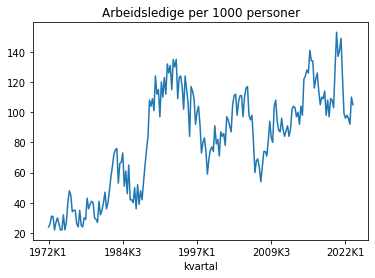

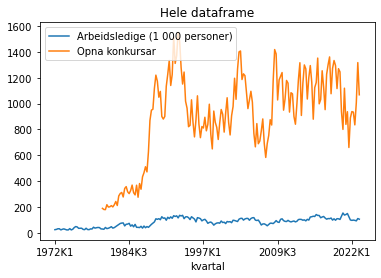

In [10]:
import matplotlib.pyplot as plt

#Plot en av kolonnene
joined_df["Arbeidsledige (1 000 personer)"].plot()
plt.title("Arbeidsledige per 1000 personer")
plt.show()

#Plot hele dataframe
joined_df.plot()
plt.title("Hele dataframe")
plt.show()

#Vi bruker eller pyplot slik vi er vant med :)

* Å finne kovarians og korrelasjon er også lett

In [11]:
joined_df.cov()

,Arbeidsledige (1 000 personer),Opna konkursar
Arbeidsledige (1 000 personer),1135.672484,6949.830975
Opna konkursar,6949.830975,117367.762175


In [12]:
joined_df.corr()

,Arbeidsledige (1 000 personer),Opna konkursar
Arbeidsledige (1 000 personer),1.000000,0.730791
Opna konkursar,0.730791,1.000000


* De som trenger en oppfriskning på kovarians og korrelasjon kan se her:


### Kovarians
<a href="https://www.youtube.com/watch?v=9Y0Alg8huJk" 
  target="_blank"><img src="https://img.youtube.com/vi/9Y0Alg8huJk/0.jpg" 
alt="IMAGE ALT TEXT HERE" width="240" height="180" border="10" /></a>

### Korrelasjon
<a href="https://www.youtube.com/watch?v=WpZi02ulCvQ" 
  target="_blank"><img src="https://img.youtube.com/vi/WpZi02ulCvQ/0.jpg" 
alt="IMAGE ALT TEXT HERE" width="240" height="180" border="10" /></a>


In [13]:
befolkning_df = pd.read_csv("06913_20231018-082252.csv", sep=";", encoding="ISO-8859-1")
#befolkning_df.index[0]

### Multiindex dataframe
* Forrige csv er en type multiindex-tabell
* Den inneholder diverse befolkningstall for hver kommune (index 0) for år mellom 1951-> (index 1)
* listen med indekser er da en liste med *tupler*
    - `index = [(Alta, 1951), (Alta, 1952), .... (Ålesund, 1951), (Ålesund, 1952) ... , (Ålesund,2023)]` 

* I tillegg begynner den faktiske dataen først på linje 4 i csv-filen
* Vi trenger å gi `read_csv` ekstra informasjon om hvordan den skal lese filen
* Merk at som default, hopper pandas over tomme linjer i csv-filen (`skip_blank_lines = True`)

In [14]:
befolkning_df = pd.read_csv("06913_20231018-082252.csv", sep=";", encoding="ISO-8859-1", index_col=[0,1], header = 1)
befolkning_df.loc['K_3001 Halden']["Døde"]

år
1951    187
1952    250
1953    256
1954    227
1955    257
       ... 
2019    299
2020    284
2021    311
2022    298
2023     ..
Name: Døde, Length: 73, dtype: object

In [15]:
indeks = befolkning_df.index
for kommune, år in indeks:
    if "Ålesund" in kommune:
        #print(kommune)
        startIndeks = kommune.find("Ålesund")
        kode = kommune[:startIndeks-1]
print(kode)
        

K_1507


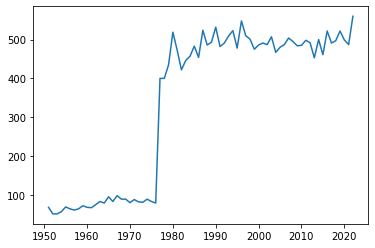

In [16]:
import matplotlib.pyplot as plt

deaths=(befolkning_df.loc['K_1507 Ålesund'])["Døde"]
deaths_int = [int(d) for d in deaths[:-1]]
years = (befolkning_df.loc['K_1507 Ålesund'])["Døde"].index
years = list(years)
plt.plot(years[:-1], deaths_int)
plt.show()